In [1]:
import boto3
import botocore
import functools
from IPython.core.display import display, HTML
from iterdub import iterdub as ib
from iterpop import iterpop as ip
import itertools as it
import json
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyanalysis import calc_loglikelihoods_by_num_sets
from dishpylib.pyanalysis import count_hands_with_k_or_more_sets
from dishpylib.pyanalysis import count_hands_without_k_or_more_sets
from dishpylib.pyanalysis import estimate_interpolation_complexity
from dishpylib.pyanalysis import calc_loglikelihoods_over_set_sizes
from dishpylib.pyhelpers import get_env_context
from dishpylib.pyhelpers import get_git_revision_hash
from dishpylib.pyhelpers import make_timestamp
from dishpylib.pyhelpers import NumpyEncoder
from dishpylib.pyhelpers import preprocess_competition_fitnesses
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmez679
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-11-30-genome-complexity-biotic
notebook path: /home/runner/work/oee4/oee4/binder/2025-11-30-genome-complexity-biotic.ipynb
revision: bdac574
timestamp: 2026-02-07T15:27:02Z00:00

IPython==7.16.1
packaging==26.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-09-05-interpolation_complexity"


In [5]:
import pandas as pd
from scipy import stats

def fit_control_t_distns(control_df):

    na_rows = control_df['Focal Prevalence'].isna()
    assert all( control_df[ na_rows ]['Population Extinct'] )
    control_df['Focal Prevalence'].fillna(0, inplace=True,)

    res = []
    for series in control_df['Competition Series'].unique():

        series_df = control_df[ control_df['Competition Series'] == series ]

        # legacy data was mixed inside of the variant_df
        # wt_vs_wt_df = series_df.groupby('Competition Repro').filter(
        #     lambda x: (x['genome variation'] == 'master').all()
        # ).groupby('Competition Repro').first().reset_index()

        # fit a t distribution to the control data
        # df is degrees of freedom
        df, loc, scale = stats.t.fit( series_df['Focal Prevalence'] )


        res.append({
            'Series' : series,
            'Fit Degrees of Freedom' : df,
            'Fit Loc' : loc,
            'Fit Scale' : scale,
        })

    return pd.DataFrame(res)


In [6]:
import boto3
import botocore
import functools
import pandas as pd

@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions-focalbb/stage=4+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )
    print("mean update", control_df["Update"].mean())

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 0
    ].copy())


In [7]:
import functools
from iterpop import iterpop as ip
from scipy import stats


def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: stats.t.cdf(
            row["Focal Prevalence"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 50
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 50)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [8]:
pd.options.display.max_columns = None


In [9]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

dfs = []
for stint in range(1, 101):
# for stint in (19,):
    print(stint)
    series_profiles, = bucket_handle.objects.filter(
        Prefix=f'endeavor=16/variant-competitions-focalbb/stage=4+what=collated/stint={stint}/',
    )
    control_fits_df = get_control_t_distns('prq49', 16, stint)
    df = pd.read_csv(
        f's3://prq49/{series_profiles.key}',
        compression='xz',
    )
    print("mean update df", df["Update"].mean())

    df["Stint"] = stint
    dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
    print(dfdigest)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    dfs.append(df)


1
mean update 7861.05
mean update df 7926.431818181818
68213c7d0f6f4a89
2
mean update 9317.9
mean update df 7638.279411764706
-2ae10ebb03b92bbe
3
mean update 7586.1
mean update df 7085.272727272727
-282fcc7266c187d1
4
mean update 8870.45
mean update df 8591.929411764706
435ea52e768948cb
5
mean update 8743.85
mean update df 8343.561643835616
3e782baaf377b2c0
6
mean update 9709.15
mean update df 9407.229885057472
238a06d0c729df9
7
mean update 9815.15
mean update df 9910.867346938776
1aaaa42c4e2ceb16
8
mean update 9012.15
mean update df 8412.54411764706
18813168c9fe21d0
9
mean update 9805.85
mean update df 9260.743243243243
-294f360c9876fa76
10
mean update 8864.35
mean update df 7773.238095238095
-5f78d9f634b2955e
11
mean update 9596.35
mean update df 8857.033333333333
-425d89b2f9ce3864
12
mean update 8810.25
mean update df 7858.611650485437
-757ed41b6acd5d8a
13
mean update 6414.3
mean update df 6824.305555555556
44ac720ff7009686
14
mean update 7479.4
mean update df 7061.105263157895
-603

In [10]:
df = pd.concat(dfs)


In [11]:
dfx = df[
    df["Root ID"] == 1
].groupby("Stint").agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
    },
)
dfx


,Is More Fit,Is Less Fit,Is Neutral
Stint,,,
1,4,9,31
2,2,20,46
3,8,14,55
4,3,23,59
5,6,15,52
...,...,...,...
96,4,817,581
97,1,45,108
98,8,57,101


Text(0, 0.5, 'Num Sites')

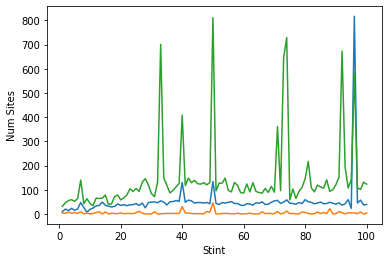

In [12]:
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is Less Fit",
)
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is More Fit",
)
sns.lineplot(
    data=dfx,
    markers=True,
    x="Stint",
    y="Is Neutral",
)
plt.gca().set_ylabel("Num Sites")


teeplots/2025-09-05-interpolation_complexity/viz=lineplot+x=stint+y=is-less-fit+ylim=None+ext=.pdf
teeplots/2025-09-05-interpolation_complexity/viz=lineplot+x=stint+y=is-less-fit+ylim=None+ext=.png


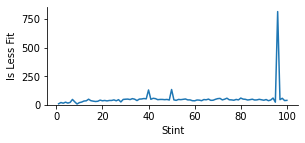

teeplots/2025-09-05-interpolation_complexity/viz=lineplot+x=stint+y=is-less-fit+ylim=100+ext=.pdf
teeplots/2025-09-05-interpolation_complexity/viz=lineplot+x=stint+y=is-less-fit+ylim=100+ext=.png


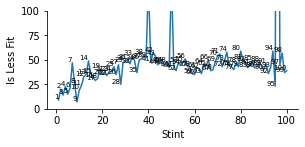

In [13]:
dfx = dfx.reset_index(drop=False)

for ylim in None, 100:
    with tp.teed(
        sns.lineplot,
        data=dfx,
        x="Stint",
        y="Is Less Fit",
        teeplot_outattrs={"ylim": ylim},
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.figure.set_size_inches(4.5, 1.8)
        sns.despine(ax=ax)
        ax.set_ylim(0, ylim)
        for x, y in zip(dfx["Stint"], dfx["Is Less Fit"]):
            if ylim is not None and y < ylim:
                plt.text(x, y, str(x), fontsize=7, ha='right', va='bottom')
